In [12]:
# set cwd
import sys
import os
# Tweak to ensure cwd is at root of repo
os.chdir('..')
print(os.getcwd())

C:\Users\monam\OneDrive\Desktop\UNI\II\PartIIProject\CST-Part-II-Project-Code


In [13]:
from typing import (
    Sequence,
    List,
    Tuple,
    Optional,
    Set,
    Dict,
)
from src.utils.qccd_nodes import *
from src.utils.qccd_operations import *
from src.utils.qccd_operations_on_qubits import *
from src.utils.qccd_arch import *
from src.compiler.qccd_parallelisation import *
from src.compiler.qccd_qubits_to_ions import *
from src.compiler.qccd_ion_routing import *
from src.compiler.qccd_alt_ion_routing import *
from src.compiler.qccd_WISE_ion_route import *
from src.compiler.qccd_color_qubits_to_ions import *

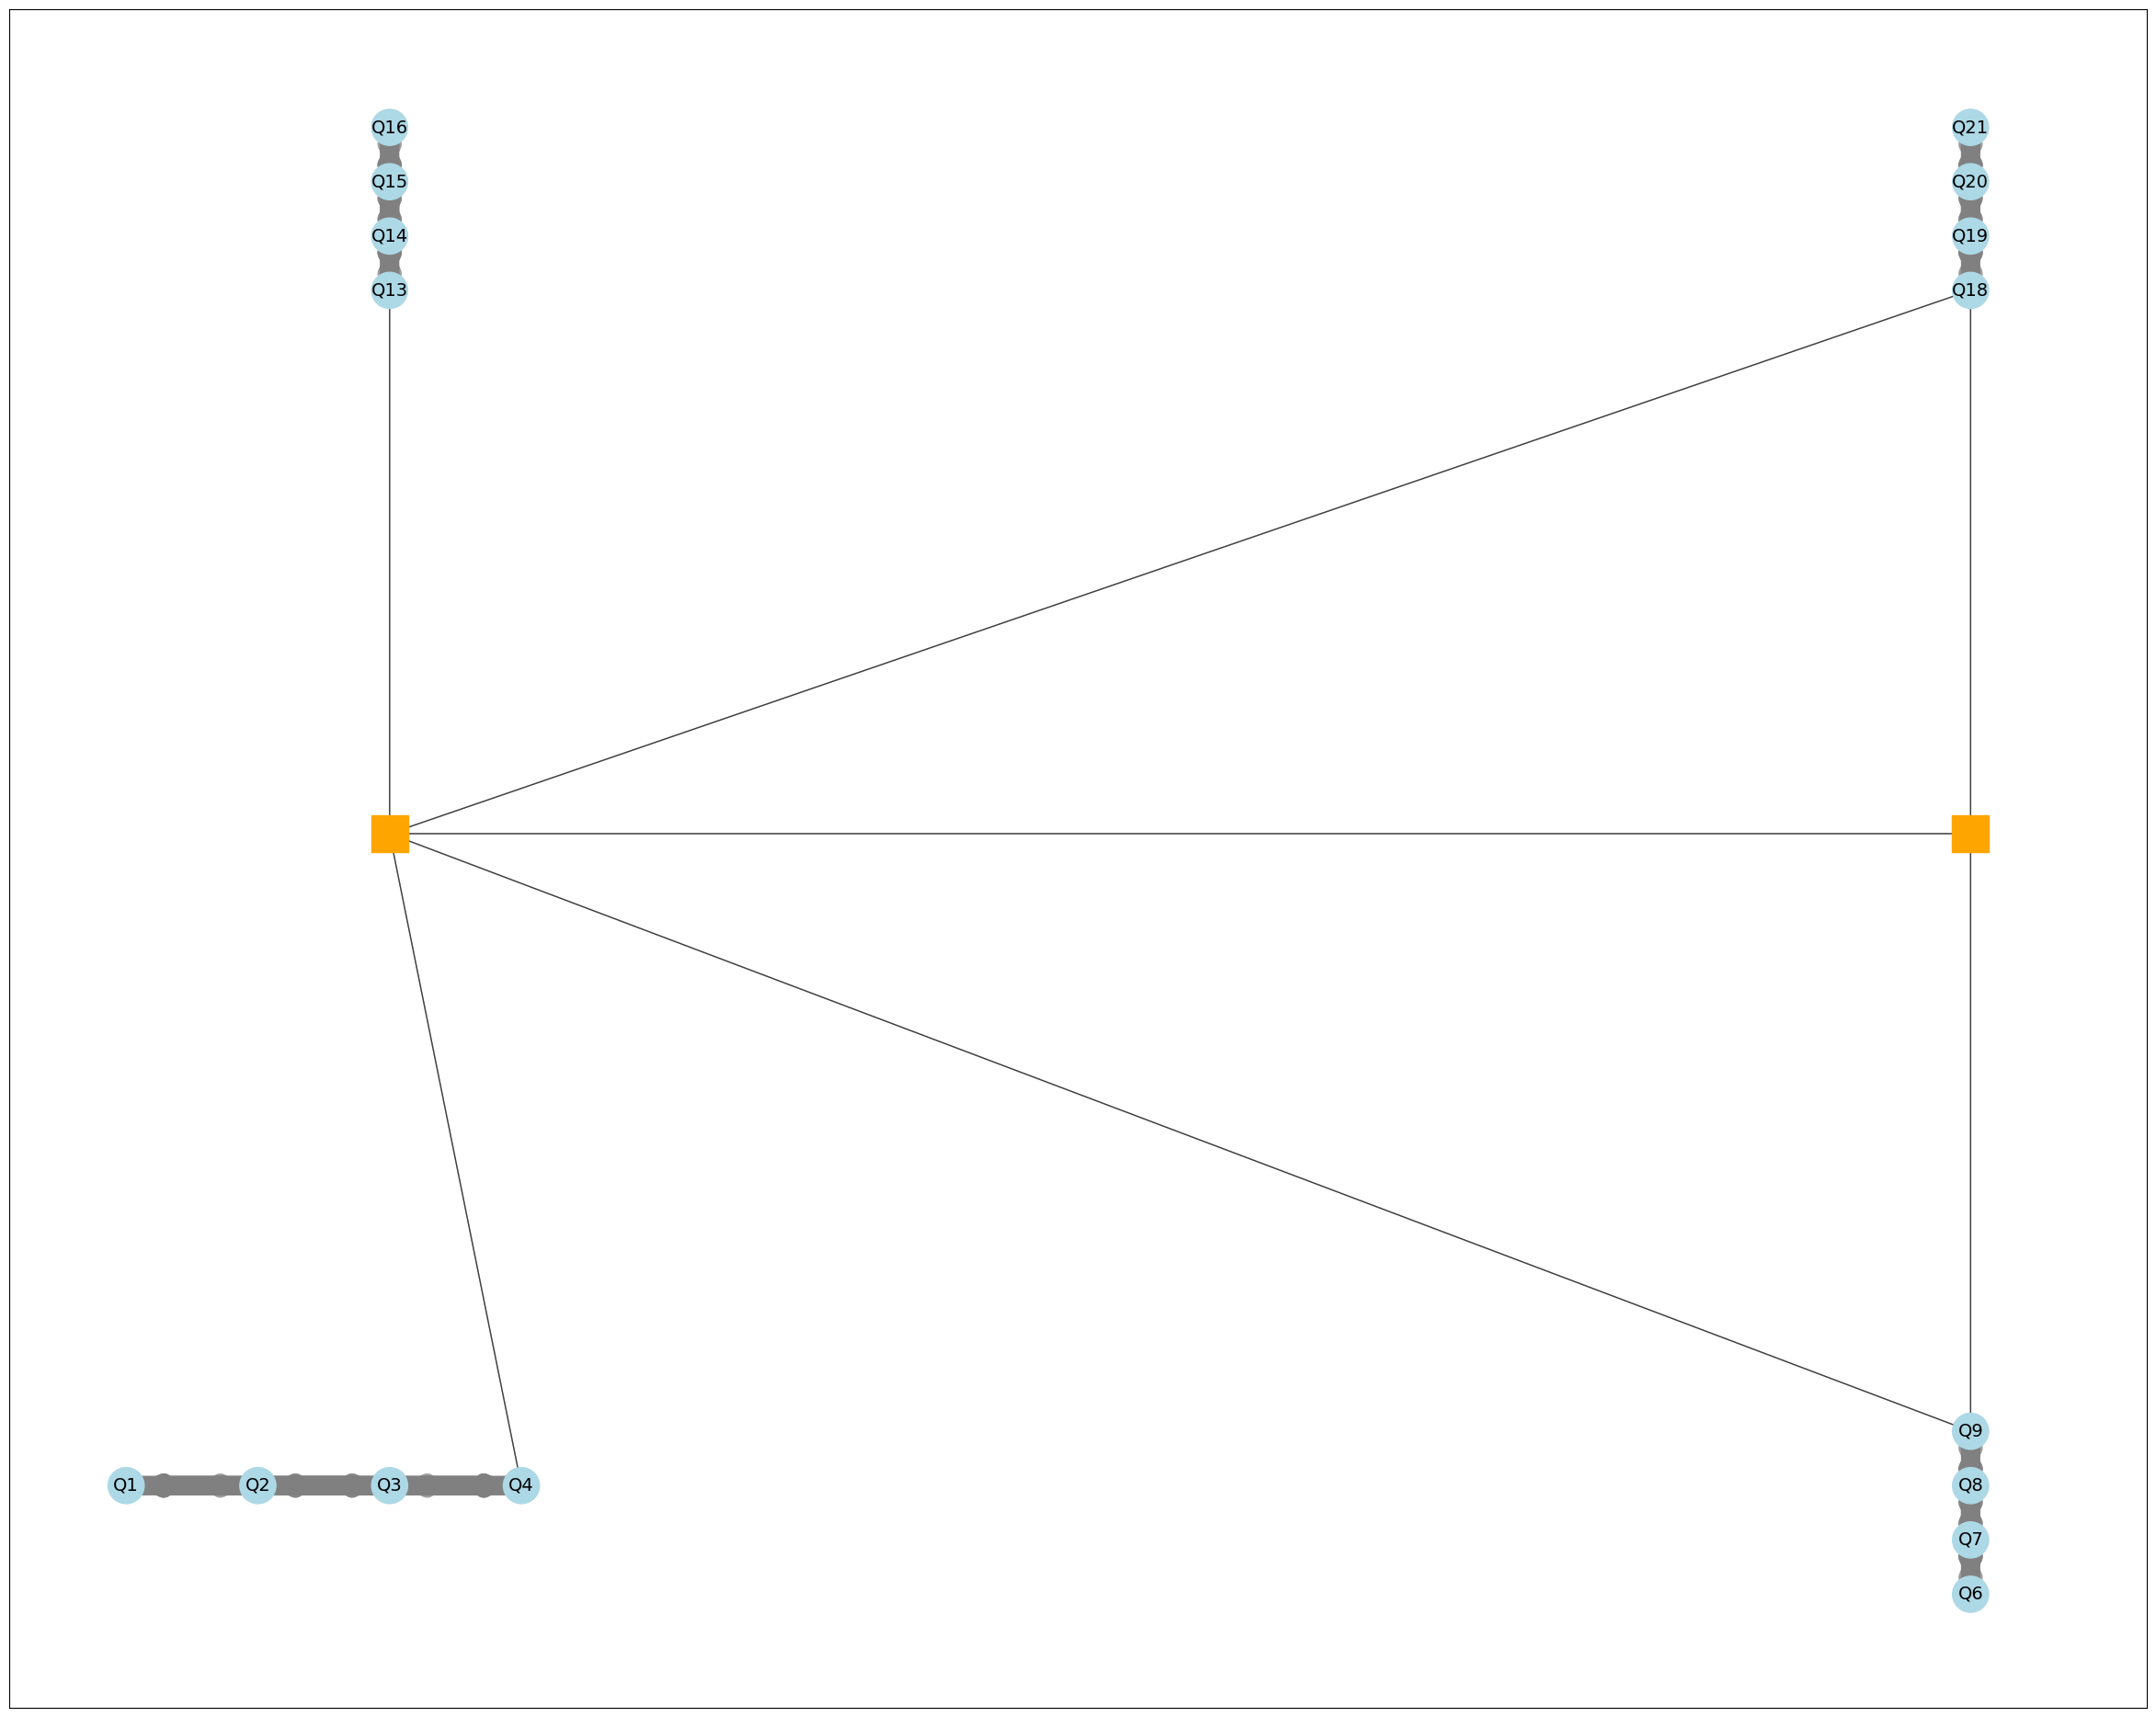

In [16]:
#testing creation of a triangular grid
"""
def processColorCircuitTriangularGrid(
    self,
    trapCapacity:int = 2,
    height:int = 1,
    width:int = 5,
    padding:int = 1,
    dataQubitIdxs:Optional[Sequence[int]]=None):

    instructions, barriers = self._parseCircuitString(dataQubitsIdxs=dataQubitsIdxs)"""

arch = QCCDArch()

ionspacing = 1
trapspacing = 6
qubit_colour = 'red'
qubit_colour = 'lightblue'
junction_colour = 'orange'
traps = []

ManipulationTrap.DEFAULT_SPACING = trapspacing
arch.SIZING = 0.5
ions11 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap11 = arch.addManipulationTrap(x=0, y=0, ions=ions11, color='grey', spacing=ionspacing, isHorizontal=True)

ions12 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap12 = arch.addManipulationTrap(x=trapspacing, y=0, ions=ions12, color='grey', spacing=ionspacing, isHorizontal=False)

junctionL = arch.addJunction(x=0, y=trapspacing, color=junction_colour)
junctionR = arch.addJunction(x=trapspacing, y=trapspacing, color=junction_colour)

ions21 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap21 = arch.addManipulationTrap(x=0, y=2*trapspacing, ions=ions21, color='grey', spacing=ionspacing, isHorizontal=False)

ions22 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap22 = arch.addManipulationTrap(x=trapspacing, y=2*trapspacing, ions=ions22, color='grey', spacing=ionspacing, isHorizontal=False)

crossing11 = arch.addEdge(trap11, junctionL)
arch.addEdge(trap12, junctionR)
crossing21 = arch.addEdge(trap21, junctionL)
arch.addEdge(trap22, junctionR)
arch.addEdge(junctionL, junctionR)
arch.addEdge(junctionL, trap12)
arch.addEdge(junctionL, trap22)

arch.refreshGraph()
# Display architecture
fig, ax = plt.subplots()
# Display architecture
arch.display(fig,ax, showLabels=False)

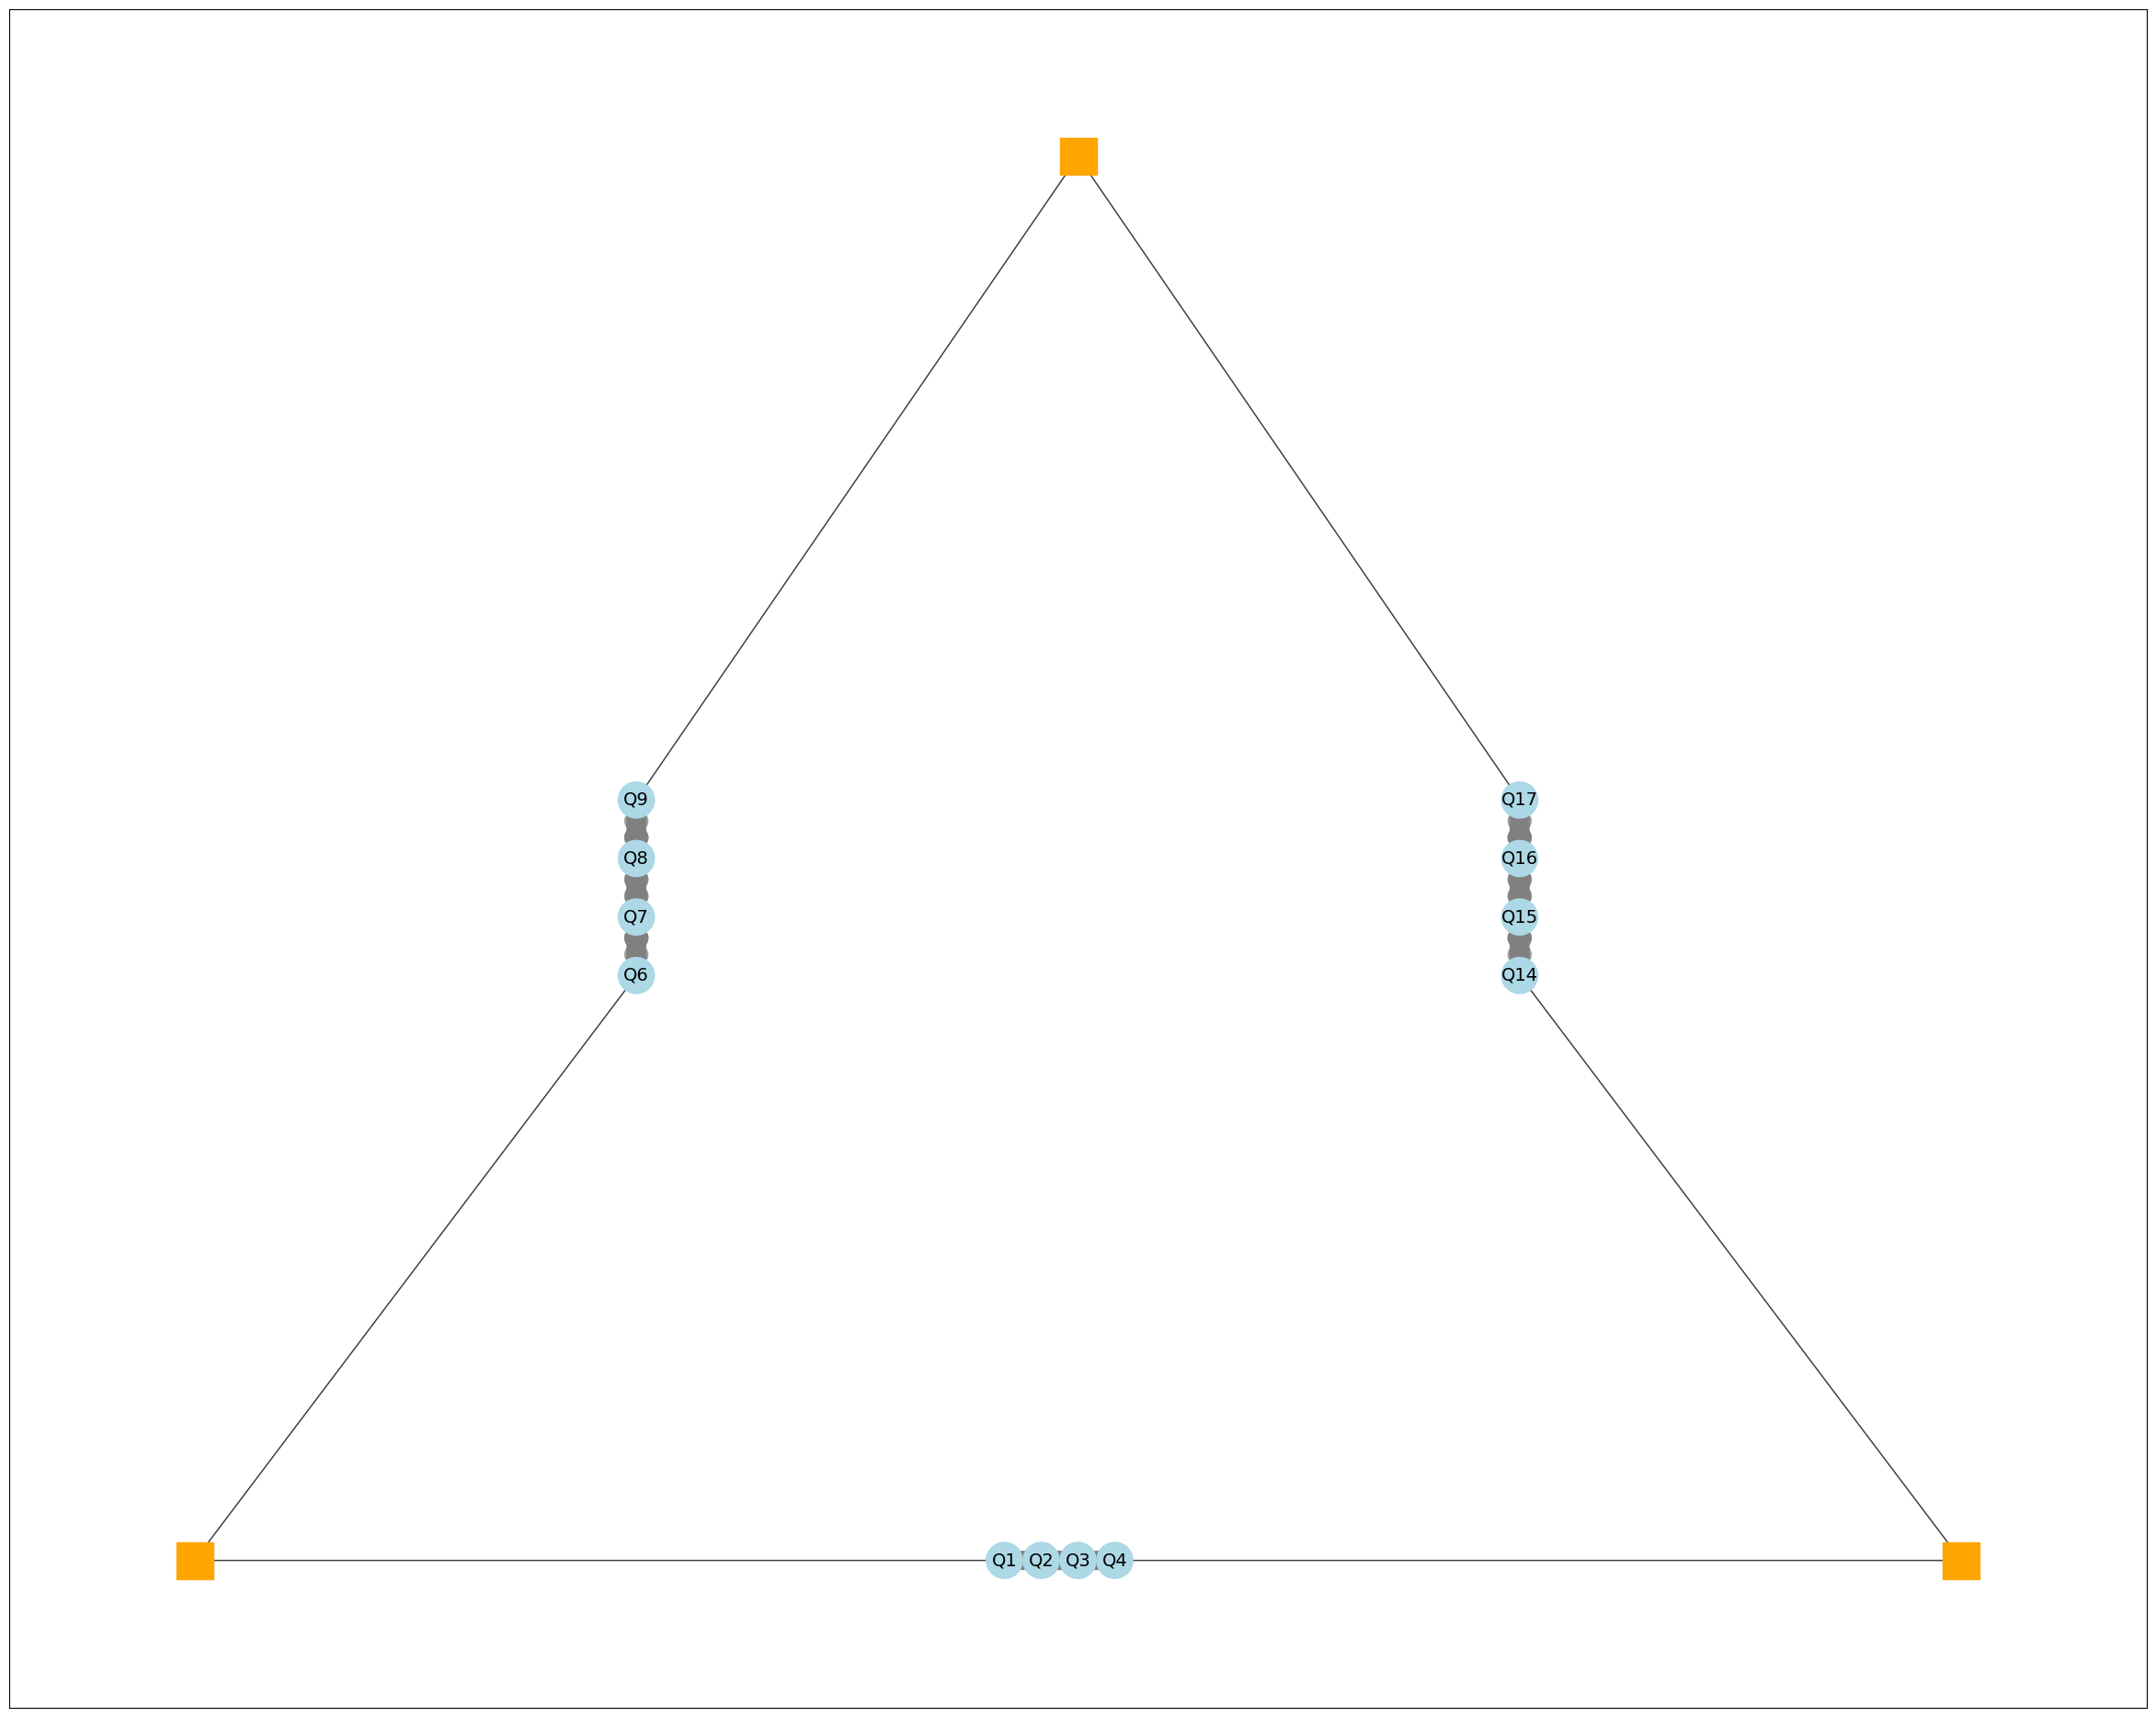

In [6]:
arch = QCCDArch()

ionspacing = 1
trapspacing = 6
qubit_colour = 'red'
qubit_colour = 'lightblue'
junction_colour = 'orange'
traps = []

ManipulationTrap.DEFAULT_SPACING = trapspacing
arch.SIZING = 0.5
ions11 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap11 = arch.addManipulationTrap(x=2*trapspacing, y=0, ions=ions11, color='grey', spacing=ionspacing, isHorizontal=True)

ions12 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap12 = arch.addManipulationTrap(x=trapspacing, y=trapspacing, ions=ions12, color='grey', spacing=ionspacing, isHorizontal=False)

junctionL = arch.addJunction(x=0, y=0, color=junction_colour)
junctionR = arch.addJunction(x=4*trapspacing, y=0, color=junction_colour)
junctionM = arch.addJunction(x=2*trapspacing, y=2*trapspacing, color=junction_colour)

ions21 = [QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q'), QubitIon(qubit_colour, 'Q'), CoolingIon(qubit_colour, 'Q')]
trap21 = arch.addManipulationTrap(x=3*trapspacing, y=trapspacing, ions=ions21, color='grey', spacing=ionspacing, isHorizontal=False)



arch.addEdge(trap11, junctionL)
arch.addEdge(trap11, junctionR)
arch.addEdge(trap12, junctionL)
arch.addEdge(trap12, junctionM)
arch.addEdge(trap21, junctionR)
arch.addEdge(trap21, junctionM)

arch.refreshGraph()
# Display architecture
fig, ax = plt.subplots()
# Display architecture
arch.display(fig,ax, showLabels=False)

In [14]:
from src.color_code_utils.color_code_circuits.color_code_circuit_666 import *
from src.compiler.qccd_qubits_to_ions import * 

cc = ColorCodeCircuit666(3,3)

print(cc.qtoid)
ids = []
coords = []
nonpcoords = []
for coord,i in cc.qtoid.items():
    ids.append(i)
    coords.append(np.array(coord))
    nonpcoords.append((coord))
#print(ids)
#print(coords)

gridpos = [(2,0), (1,1), (3,1)]

parts = TriangularPartitionIons(ids, np.array(coords),10)
print(f'clusters: {parts}')
arrangeClusters(parts, gridpos)

{(0, 0): 0, (1, 1): 1, (2, 0): 2, (2, 2): 3, (3, 1): 4, (3, 3): 5, (4, 0): 6, (4, 2): 7, (5, 1): 8, (6, 0): 9}
clusters: [([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], (np.float64(3.0), np.float64(1.0)))]


[array([3, 1])]

In [11]:
padding = 1
h = 5
w = 3
gridPos = []
for j in range(h):
    offset = (j%2)*2
    wr = w-1 if offset else w
    for i in range(wr):
        gridPos.append((4*i + offset, j*2))
print(gridPos)

[(0, 0), (4, 0), (8, 0), (2, 2), (6, 2), (0, 4), (4, 4), (8, 4), (2, 6), (6, 6), (0, 8), (4, 8), (8, 8)]


In [ ]:

def processCircuitTriGrid(
    self,
    trapCapacity: int = 2,
    rows: int = 1, #num of rows/height
    cols: int = 5, #num of cols/width
    padding: int = 1,
    dataQubitIdxs: Optional[Sequence[int]] = None):
    instructions, barriers = self._parseCircuitString(dataQubitsIdxs=dataQubitIdxs)
    
    if (trapCapacity - 1) * (rows * cols - (rows//2)) < len(self._ionMapping):
        raise ValueError("processCircuit: not enough traps")

    clusters = regularPartition(self._measurementIons, self._dataIons, trapCapacity)

    cs, rs = cols, rows
    allGridPos = []
    for j in range(rows):
        offset = (j%2)*2
        rowrange = cs - 1 if offset else cs
        for i in range(rowrange):
            allGridPos.append((4*i + offset, j*2))

    gridPositions = hillClimbOnArrangeClusters(clusters, allGridPos=allGridPos)
    gridPositions = [(c+padding, r+padding) for (c,r) in gridPositions]
    rows = rows+2*padding
    cols = cols+2*padding
    trap_for_grid = { (col,row): clusters[trapIdx] for trapIdx, (col,row) in enumerate(gridPositions)}
    self._originalArrangement = {}

    self._arch = QCCDArch()
    traps_dict = {}

    # add traps
    for j in range(rows):
        offset = (j%2)*2
        widthrange = cols -1 if offset else cols
        for i in range(widthrange):
            if (4*i+offset, j*2) in trap_for_grid:
                ions = trap_for_grid[(4*i+offset, j*2)][0]
            else:
                ions = []
            traps_dict[(4*i+offset, j*2)] = self._arch.addManipulationTrap(
                *self._gridTOCoordinate((2*col, 2*row), trapCapacity),
                ions,
                color=self.TRAP_COLOR,
                isHorizontal=(j%2==0),
                capacity=trapCapacity
            )
            self._originalArrangement[traps_dict[(4*i+offset, j*2)]] = ions

        if j == rows-1:
            break

    # add junctions